In [ ]:
# pandas & numpy : data handling
# matplotlib     : base plotting library
# seaborn        : beautiful statistical plots built on matplotlib
# plotly.express : interactive charts
# os             : file path handling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Set the visual style for all seaborn plots
sns.set_theme(style="whitegrid", palette="husl")

# Set default figure size for matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
 
# Create reports folder if it doesn't exist
os.makedirs('../reports', exist_ok=True)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [2]:
# Load the cleaned raw dataset
df = pd.read_csv('../data/raw/diabetes.csv')

# Separate features and target for easy use later
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print(f"Dataset loaded ✅  Shape: {df.shape}")
df.head()

Dataset loaded ✅  Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


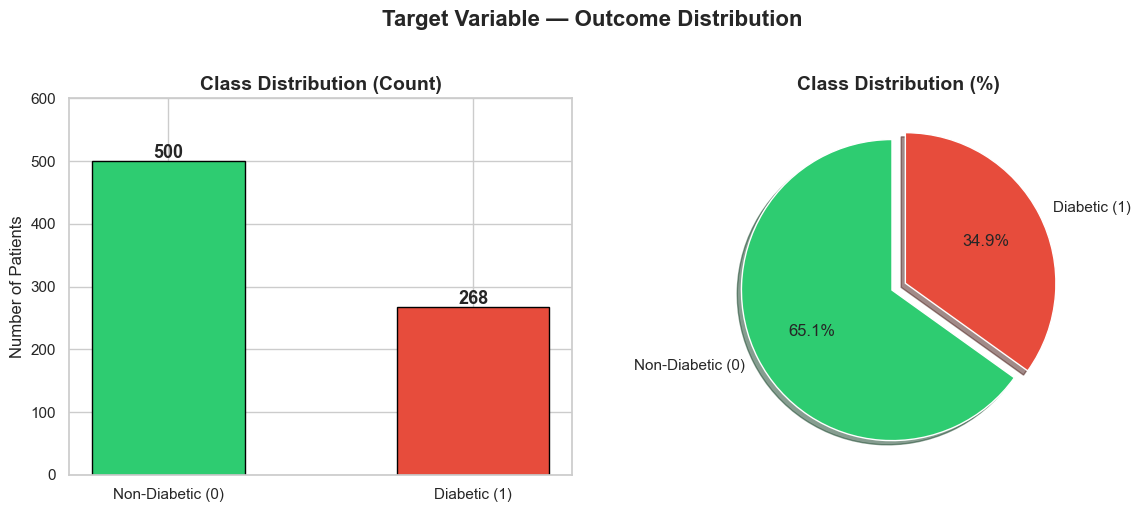

✅ Plot saved to reports/01_class_distribution.png


In [3]:
# -------------------------------------------------------
# PLOT 1: Class Distribution (Diabetic vs Non-Diabetic)
# -------------------------------------------------------
# This tells us how balanced our target variable is.
# If heavily imbalanced, our model might be biased.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar Chart ---
outcome_counts = df['Outcome'].value_counts()
bars = axes[0].bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    outcome_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
# Add count labels on top of each bar
for bar, count in zip(bars, outcome_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', fontweight='bold', fontsize=13
    )
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, 600)

# --- Pie Chart ---
axes[1].pie(
    outcome_counts.values,
    labels=['Non-Diabetic (0)', 'Diabetic (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.05, 0.05),
    shadow=True,
    startangle=90
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Outcome Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/01_class_distribution.png")

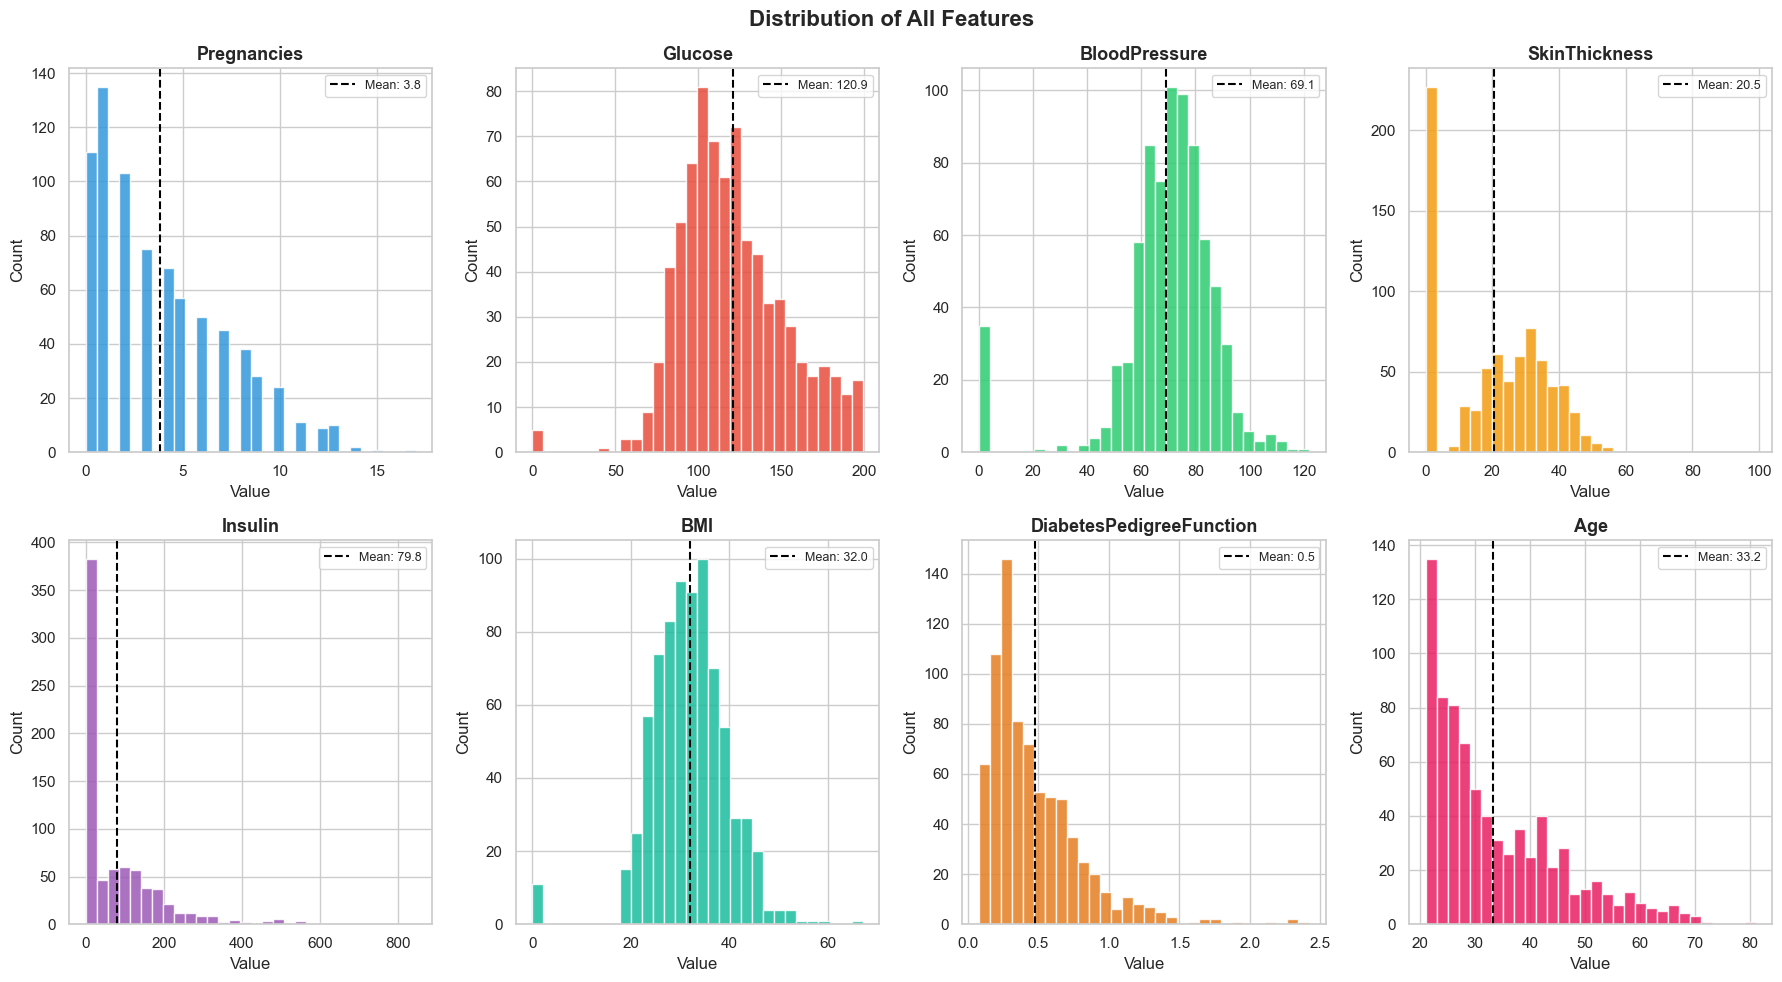

✅ Plot saved to reports/02_feature_distributions.png


In [4]:
# -------------------------------------------------------
# PLOT 2: Distribution of all 8 features
# -------------------------------------------------------
# A histogram shows how values of a feature are spread.
# - Normal bell shape = good
# - Skewed = might need transformation
# - Spike at 0 = hidden missing values!

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()  # Convert 2D array to 1D for easy looping

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']

for i, feature in enumerate(features):
    axes[i].hist(
        df[feature],
        bins=30,
        color=colors[i],
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

    # Add a vertical line at mean
    mean_val = df[feature].mean()
    axes[i].axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/02_feature_distributions.png")

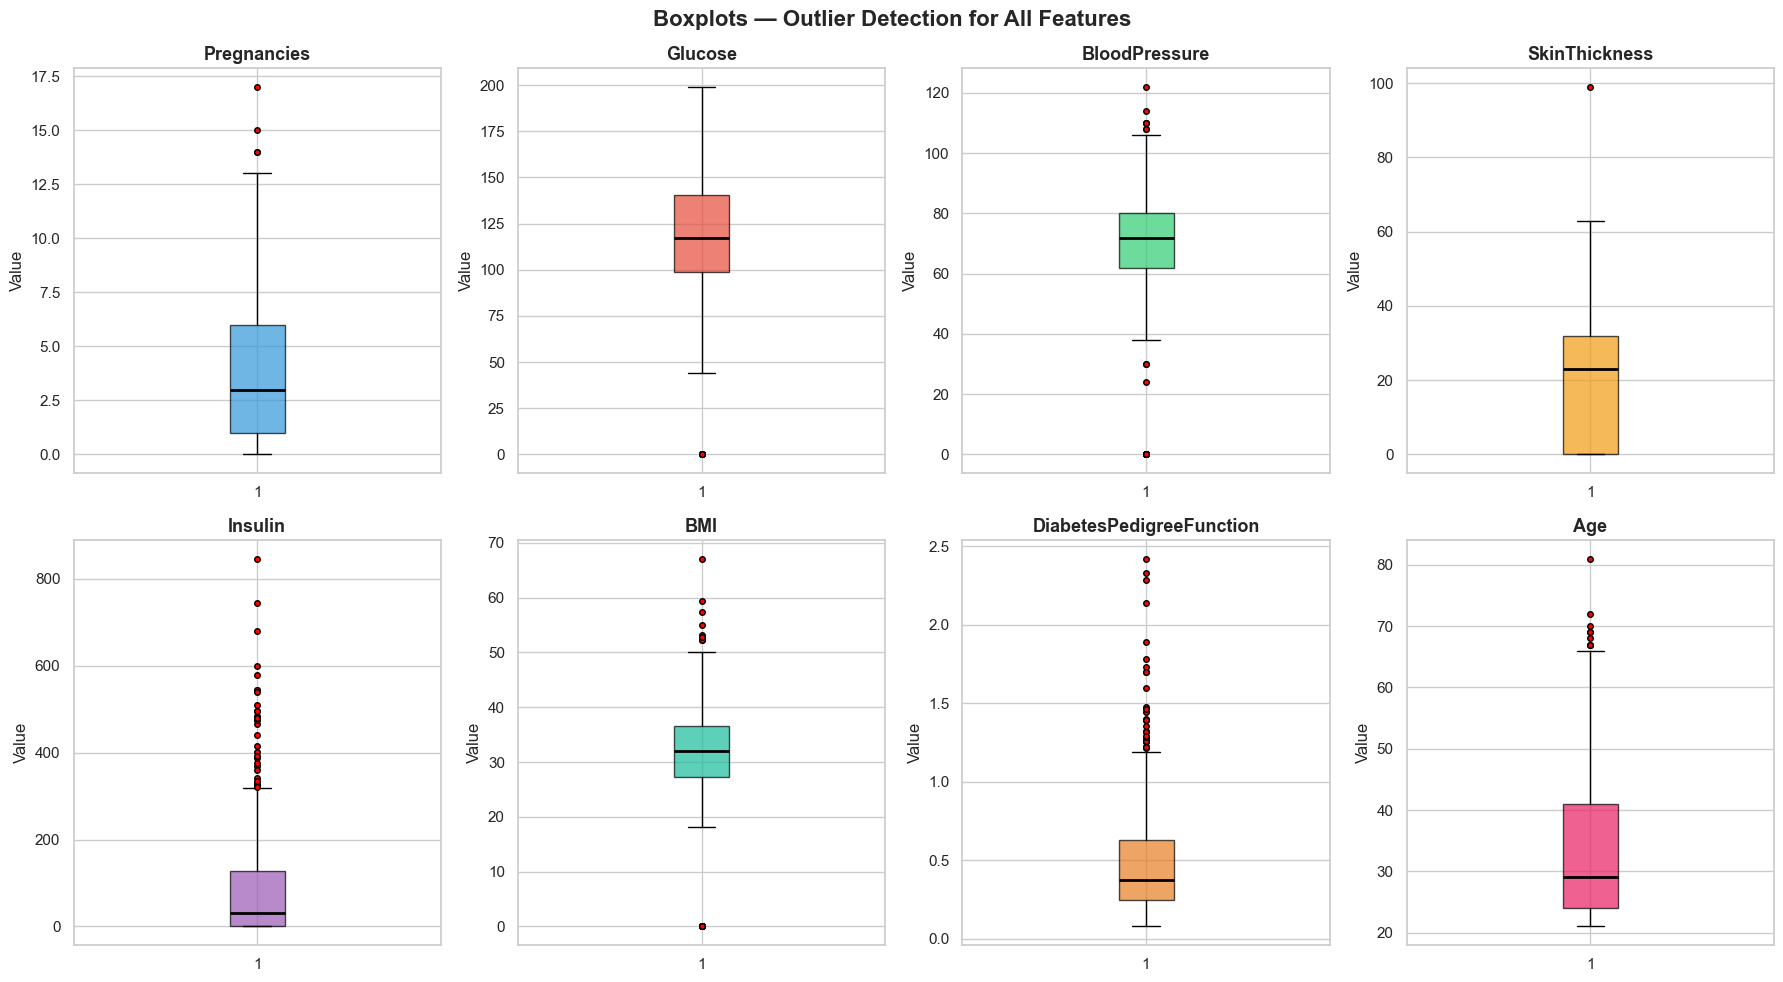

✅ Plot saved to reports/03_boxplots_outliers.png


In [5]:
# -------------------------------------------------------
# PLOT 3: Boxplots for each feature
# -------------------------------------------------------
# A boxplot shows:
# - The box     = middle 50% of data (IQR)
# - The line    = median
# - The whiskers= normal range
# - The dots    = OUTLIERS (unusual values)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(
        df[feature],
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
    )
    axes[i].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection for All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/03_boxplots_outliers.png")

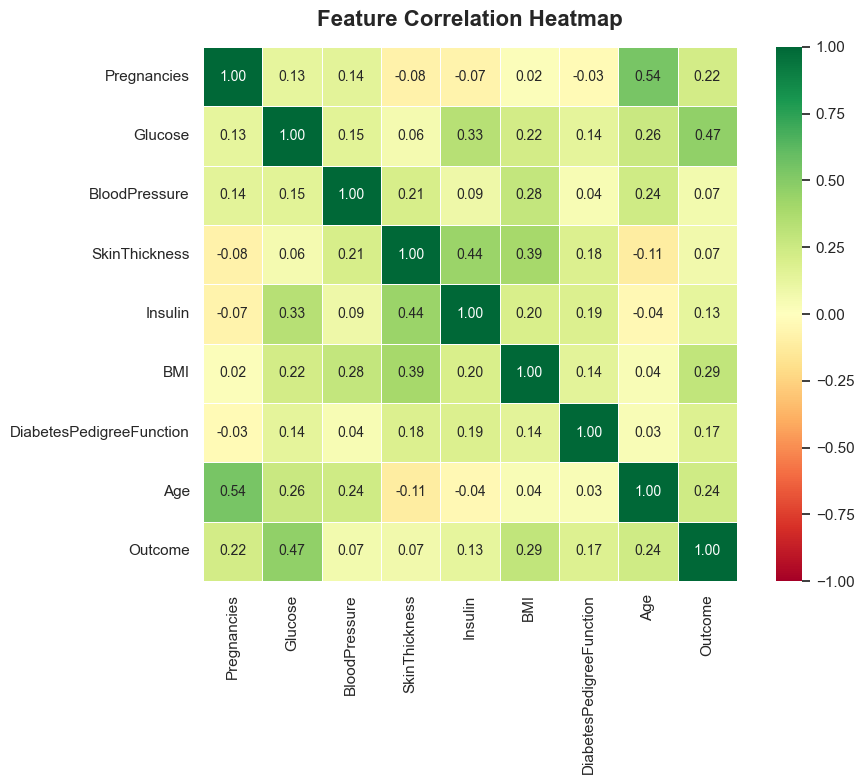

✅ Plot saved to reports/04_correlation_heatmap.png


In [6]:
# -------------------------------------------------------
# PLOT 4: Correlation Heatmap
# -------------------------------------------------------
# Correlation tells us how strongly two features are related.
# Value ranges from -1 to +1:
# +1 = perfectly positively correlated (both increase together)
# -1 = perfectly negatively correlated (one goes up, other goes down)
#  0 = no relationship
#
# For ML: High correlation with 'Outcome' = important feature!

plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = df.corr()

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # Show numbers in each cell
    fmt='.2f',            # Round to 2 decimal places
    cmap='RdYlGn',        # Red=negative, Yellow=neutral, Green=positive
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1,
    annot_kws={'size': 10}
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/04_correlation_heatmap.png")

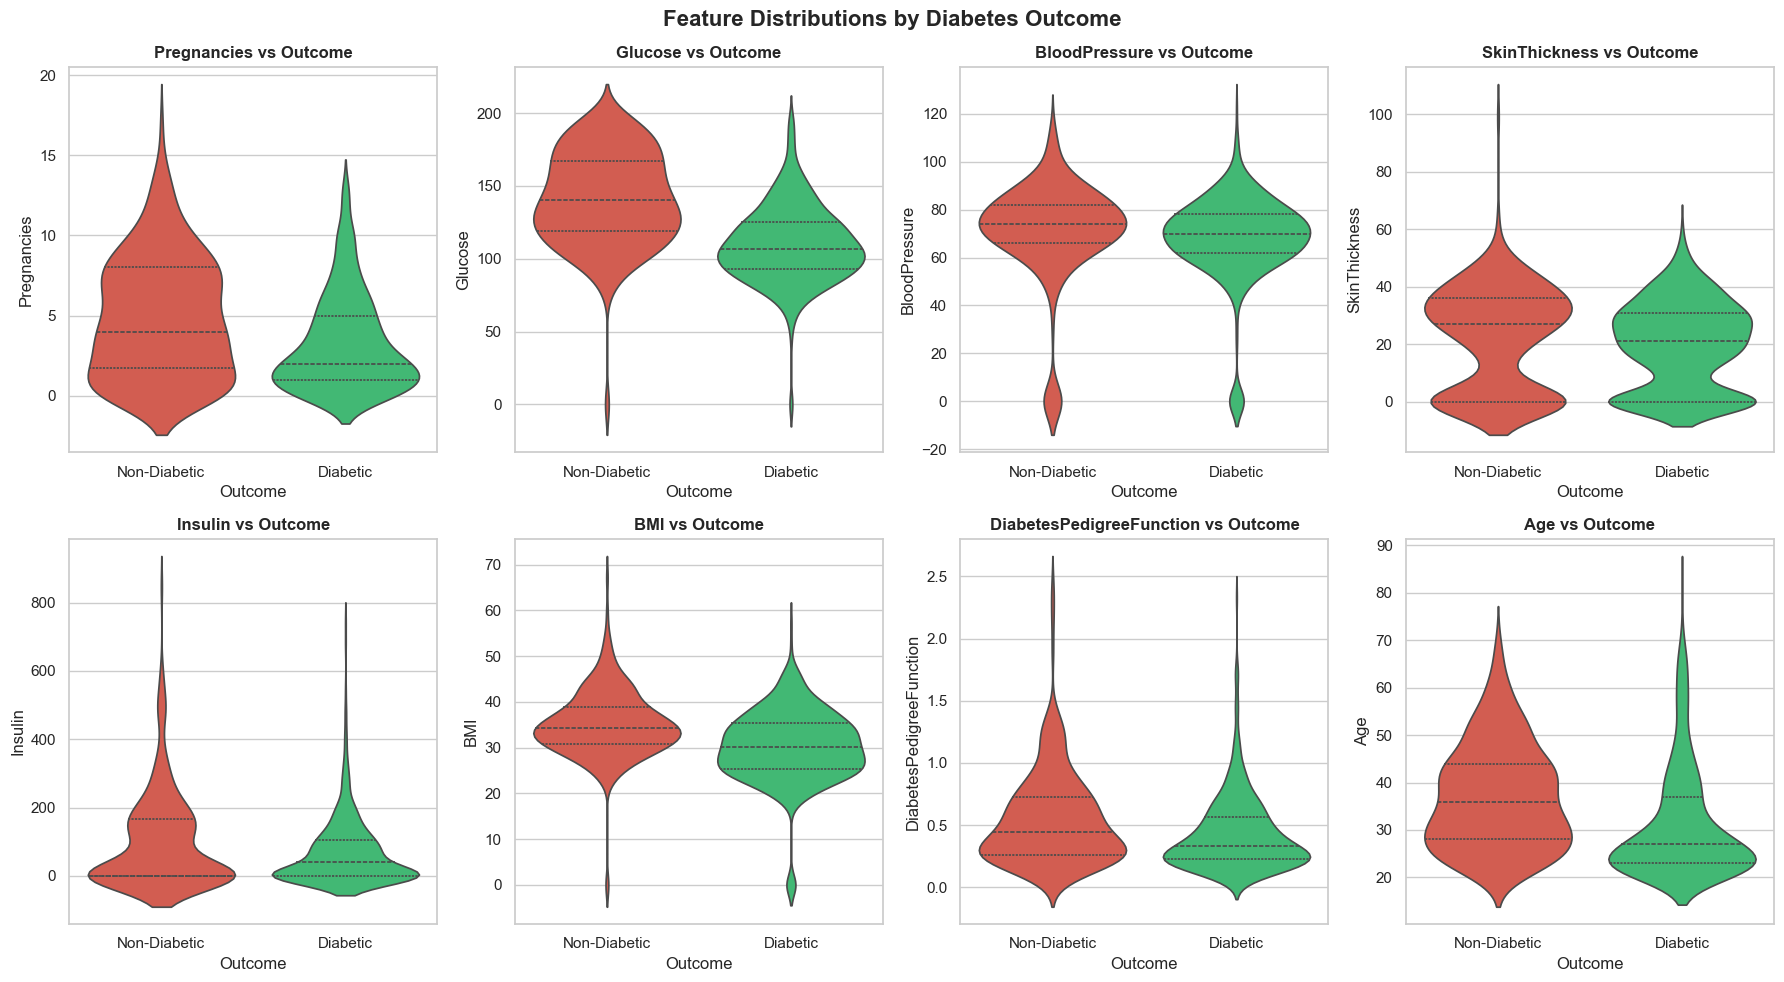

✅ Plot saved to reports/05_violin_plots.png


In [8]:
# -------------------------------------------------------
# PLOT 5: Violin Plots — Feature distribution by Outcome
# -------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Fix: create a labeled copy for hue to work correctly in newer seaborn
    plot_df = df[[feature, 'Outcome']].copy()
    plot_df['Outcome'] = plot_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

    sns.violinplot(
        data=plot_df,
        x='Outcome',
        y=feature,
        hue='Outcome',              # ← Fix: explicitly pass hue
        palette={'Non-Diabetic': '#2ecc71', 'Diabetic': '#e74c3c'},
        ax=axes[i],
        inner='quartile',
        legend=False                # ← Fix: hide redundant legend
    )
    axes[i].set_title(f'{feature} vs Outcome', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Outcome')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/05_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/05_violin_plots.png")

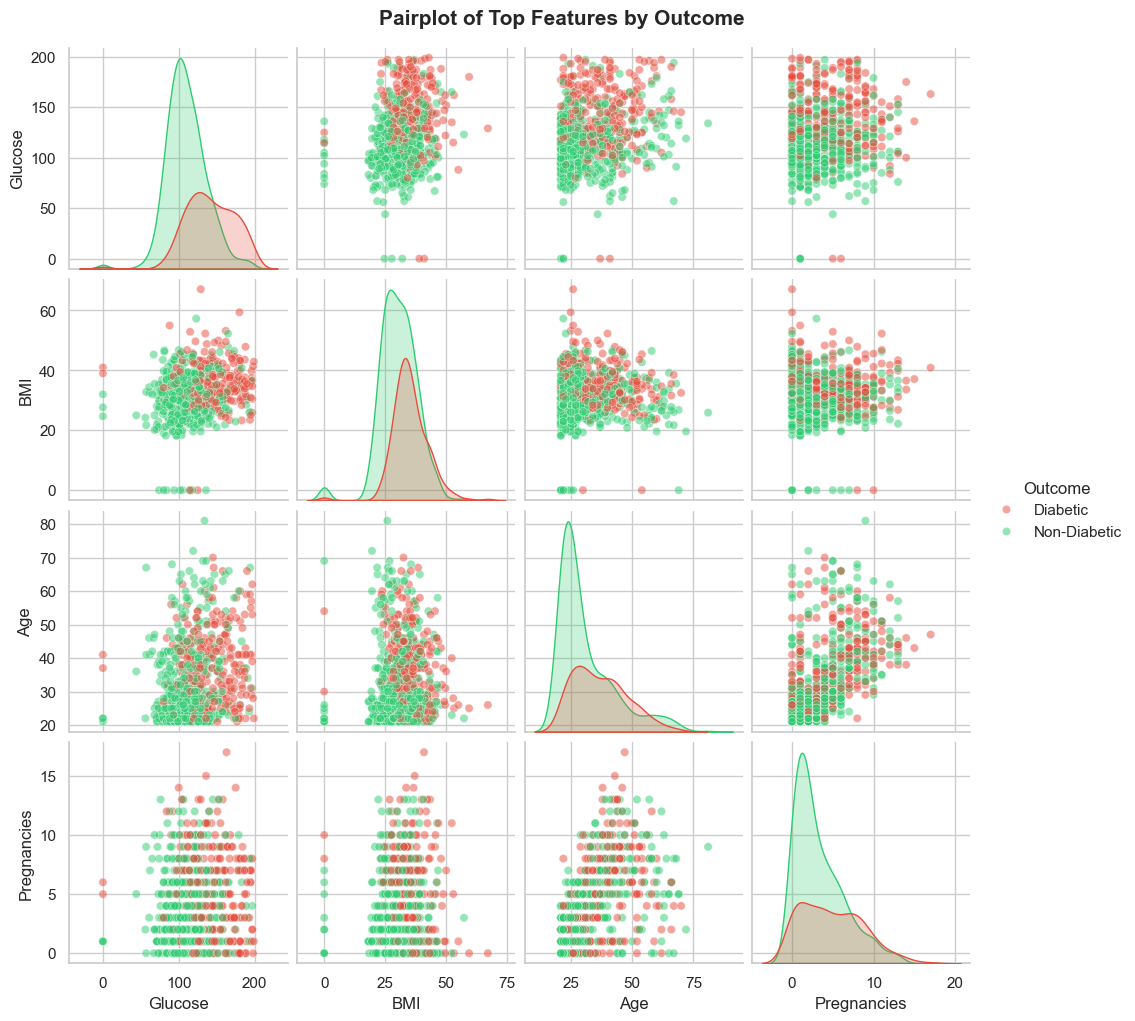

✅ Plot saved to reports/06_pairplot.png


In [9]:
# -------------------------------------------------------
# PLOT 6: Pairplot — Relationships between top features
# -------------------------------------------------------
# A pairplot shows scatter plots between every pair of features.
# Color = Outcome (green=healthy, red=diabetic)
# This helps us see if features can SEPARATE the two classes.

# Use only top features to keep it readable
top_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']

pair_df = df[top_features].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

pairplot = sns.pairplot(
    pair_df,
    hue='Outcome',
    palette={'Non-Diabetic': '#2ecc71', 'Diabetic': '#e74c3c'},
    diag_kind='kde',       # Diagonal: smooth distribution curve
    plot_kws={'alpha': 0.5}
)

pairplot.fig.suptitle('Pairplot of Top Features by Outcome', y=1.02,
                       fontsize=15, fontweight='bold')
plt.savefig('../reports/06_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved to reports/06_pairplot.png")

In [10]:
# -------------------------------------------------------
# PLOT 7: Interactive Scatter Plot (Plotly)
# -------------------------------------------------------
# This is an INTERACTIVE chart — you can hover, zoom, filter!
# We plot Glucose vs BMI, colored by Outcome.
# Size of dot = Age (bigger dot = older patient)

plot_df = df.copy()
plot_df['Outcome_Label'] = plot_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

fig = px.scatter(
    plot_df,
    x='Glucose',
    y='BMI',
    color='Outcome_Label',
    size='Age',
    hover_data=['Age', 'Insulin', 'BloodPressure'],
    color_discrete_map={'Non-Diabetic': '#2ecc71', 'Diabetic': '#e74c3c'},
    title='Interactive: Glucose vs BMI (sized by Age)',
    labels={'Glucose': 'Glucose Level', 'BMI': 'Body Mass Index'}
)

fig.update_layout(
    title_font_size=16,
    legend_title='Diagnosis',
    height=550
)

fig.show()
print("✅ Interactive chart displayed")

✅ Interactive chart displayed


In [11]:
print("=" * 55)
print("        PHASE 3 — EDA VISUAL SUMMARY")
print("=" * 55)
print()
print("📊 Plots generated and saved to /reports/:")
plots = [
    "01_class_distribution.png  → Class imbalance confirmed",
    "02_feature_distributions.png → Zeros visible in Insulin/Skin",
    "03_boxplots_outliers.png   → Outliers found in Insulin/BMI",
    "04_correlation_heatmap.png → Glucose most correlated feature",
    "05_violin_plots.png        → Glucose/BMI differ by outcome",
    "06_pairplot.png            → Glucose+BMI separate classes well",
]
for p in plots:
    print(f"  ✅ {p}")

print()
print("🔑 Key Insights:")
print("  1. Glucose is the strongest predictor of diabetes")
print("  2. BMI and Age are also important features")
print("  3. Insulin & SkinThickness have too many zeros (missing)")
print("  4. Class imbalance: 65% Non-Diabetic vs 35% Diabetic")
print("  5. Several outliers present, especially in Insulin")
print()
print("➡️  All issues will be addressed in Phase 4: Preprocessing")
print("=" * 55)

        PHASE 3 — EDA VISUAL SUMMARY

📊 Plots generated and saved to /reports/:
  ✅ 01_class_distribution.png  → Class imbalance confirmed
  ✅ 02_feature_distributions.png → Zeros visible in Insulin/Skin
  ✅ 03_boxplots_outliers.png   → Outliers found in Insulin/BMI
  ✅ 04_correlation_heatmap.png → Glucose most correlated feature
  ✅ 05_violin_plots.png        → Glucose/BMI differ by outcome
  ✅ 06_pairplot.png            → Glucose+BMI separate classes well

🔑 Key Insights:
  1. Glucose is the strongest predictor of diabetes
  2. BMI and Age are also important features
  3. Insulin & SkinThickness have too many zeros (missing)
  4. Class imbalance: 65% Non-Diabetic vs 35% Diabetic
  5. Several outliers present, especially in Insulin

➡️  All issues will be addressed in Phase 4: Preprocessing
